# Part 2: The Broadcasting Bug

**Goal:** Understand exactly what breaks when `keepdims=False` in softmax, and observe its effect on training.

---

## 2.1 The Bug Explained

### What Should Happen

For row-wise softmax, we want:
$$
A_{ij} = \frac{e^{S_{ij}}}{\sum_k e^{S_{ik}}}
$$

Each row is normalized by **its own** sum. Rows should sum to 1.

### What Goes Wrong

With `keepdims=False`:
```python
exp_scores.shape = (n, n)
row_sums.shape = (n,)  # NOT (n, 1)!
```

NumPy broadcasting aligns from the **right**:
- `(n, n) / (n,)` broadcasts the divisor across **columns**
- Column $j$ gets divided by `row_sums[j]` — the sum of row $j$, not its own row!

**Result:** Each element $A_{ij}$ is divided by the wrong normalizer.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Core functions (copied from Part 1 for standalone execution)
# ============================================================

def generate_argmax_sample(dim=4, value_range=(0, 10), seed=None):
    """Toy task: input x is length-dim ints; target y repeats argmax(x)."""
    if seed is not None:
        np.random.seed(seed)
    x = np.random.randint(value_range[0], value_range[1], size=(dim,))
    max_val = np.max(x)
    y = np.full((dim,), max_val)
    return x, y


def row_softmax(scores: np.ndarray) -> np.ndarray:
    """Row-wise softmax (numerically stable). CORRECT version."""
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def row_softmax_buggy(scores: np.ndarray) -> np.ndarray:
    """Buggy softmax: missing keepdims — broadcasts across columns."""
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1)  # BUG: no keepdims


def attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=False, softmax_fn=None):
    """Single-head self-attention + output projection."""
    if softmax_fn is None:
        softmax_fn = row_softmax
    d_k = W_Q.shape[1]
    Q = hidden_layer @ W_Q
    K = hidden_layer @ W_K
    V = hidden_layer @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    A = softmax_fn(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    cache = {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}
    return H, cache


def mse(pred, target):
    return np.mean((pred - target) ** 2)


def attention_step(W_Q, W_K, W_V, W_H, hidden_layer, target, lr=1e-3, clip=1.0, softmax_fn=None):
    """One SGD step; returns updated weights, loss, cache, gradient norms."""
    pred, cache = attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=True, softmax_fn=softmax_fn)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)
    
    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T
    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))
    
    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)
    dW_Q = hidden_layer.T @ dQ
    dW_K = hidden_layer.T @ dK
    dW_V = hidden_layer.T @ dV
    
    grad_norms = {
        "W_Q": float(np.linalg.norm(dW_Q)),
        "W_K": float(np.linalg.norm(dW_K)),
        "W_V": float(np.linalg.norm(dW_V)),
        "W_H": float(np.linalg.norm(dW_H)),
    }
    
    dW_Q = np.clip(dW_Q, -clip, clip)
    dW_K = np.clip(dW_K, -clip, clip)
    dW_V = np.clip(dW_V, -clip, clip)
    dW_H = np.clip(dW_H, -clip, clip)
    
    W_Q = W_Q - lr * dW_Q
    W_K = W_K - lr * dW_K
    W_V = W_V - lr * dW_V
    W_H = W_H - lr * dW_H
    
    return W_Q, W_K, W_V, W_H, loss, cache, grad_norms


def make_hidden_and_target(x_raw, y_raw, W_embed, scale=10.0):
    """Embed scalars into d_model space."""
    x = (np.array(x_raw, dtype=np.float64).reshape(-1, 1)) / scale
    y = (np.array(y_raw, dtype=np.float64).reshape(-1, 1)) / scale
    return x @ W_embed, y @ W_embed


def decode_embedding_to_scalar(embedded, W_embed, scale=10.0):
    """Project back to scalar space."""
    w = W_embed.reshape(-1)
    return (embedded @ w) / (w @ w + 1e-12) * scale


def attention_row_entropy(A: np.ndarray) -> float:
    """Mean entropy across rows of attention matrix."""
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    H = -np.sum(P * np.log(P), axis=1)
    return float(np.mean(H))


print("All functions loaded. Ready to run.")

All functions loaded. Ready to run.


## 2.2 Visualizing the Bug

In [18]:
# Create a score matrix where rows have different magnitudes
scores_demo = np.array([
    [1.0, 2.0, 3.0, 4.0],   # row 0: ascending
    [4.0, 3.0, 2.0, 1.0],   # row 1: descending
    [0.0, 0.0, 0.0, 0.0],   # row 2: uniform
    [10., 10., 10., 10.],   # row 3: large uniform
])

# Apply numerical stability shift
exp_scores = np.exp(scores_demo - np.max(scores_demo, axis=1, keepdims=True))

print("=== Score Matrix ===")
print(scores_demo)
print("\n=== Exp(Scores) ===")
print(np.round(exp_scores, 4))

=== Score Matrix ===
[[ 1.  2.  3.  4.]
 [ 4.  3.  2.  1.]
 [ 0.  0.  0.  0.]
 [10. 10. 10. 10.]]

=== Exp(Scores) ===
[[0.0498 0.1353 0.3679 1.    ]
 [1.     0.3679 0.1353 0.0498]
 [1.     1.     1.     1.    ]
 [1.     1.     1.     1.    ]]


In [19]:
# Row sums with and without keepdims
row_sums_correct = np.sum(exp_scores, axis=1, keepdims=True)  # shape (4, 1)
row_sums_buggy = np.sum(exp_scores, axis=1)                   # shape (4,)

print("Row sums (keepdims=True) — shape", row_sums_correct.shape)
print(row_sums_correct)

print("\nRow sums (keepdims=False) — shape", row_sums_buggy.shape)
print(row_sums_buggy)

Row sums (keepdims=True) — shape (4, 1)
[[1.55300179]
 [1.55300179]
 [4.        ]
 [4.        ]]

Row sums (keepdims=False) — shape (4,)
[1.55300179 1.55300179 4.         4.        ]


In [20]:
# Apply softmax both ways
A_correct = row_softmax(scores_demo)
A_buggy = row_softmax_buggy(scores_demo)

print("=== Correct Softmax ===")
print(np.round(A_correct, 4))
print("Row sums:", np.round(A_correct.sum(axis=1), 6))

print("\n=== Buggy Softmax ===")
print(np.round(A_buggy, 4))
print("Row sums:", np.round(A_buggy.sum(axis=1), 6))  # NOT 1!

=== Correct Softmax ===
[[0.0321 0.0871 0.2369 0.6439]
 [0.6439 0.2369 0.0871 0.0321]
 [0.25   0.25   0.25   0.25  ]
 [0.25   0.25   0.25   0.25  ]]
Row sums: [1. 1. 1. 1.]

=== Buggy Softmax ===
[[0.0321 0.0871 0.092  0.25  ]
 [0.6439 0.2369 0.0338 0.0124]
 [0.6439 0.6439 0.25   0.25  ]
 [0.6439 0.6439 0.25   0.25  ]]
Row sums: [0.461173 0.927078 1.787829 1.787829]


### Key Observation

- **Correct softmax:** Every row sums to exactly 1.0
- **Buggy softmax:** Row sums are arbitrary (not probability distributions!)

This breaks the interpretation of attention weights as "how much to attend to each position."

In [21]:
# Instrument: fail-fast invariant checks (this is what you'd put in debug/CI)

def assert_row_stochastic(A: np.ndarray, atol: float = 1e-6) -> None:
    """Raise if A isn't a valid row-wise probability matrix."""
    if not np.all(np.isfinite(A)):
        raise ValueError("Non-finite values in A (NaN/Inf).")

    min_val = float(np.min(A))
    if min_val < -atol:
        raise ValueError(f"Negative values in A (min={min_val:.3e}).")

    row_sums = A.sum(axis=1)
    max_err = float(np.max(np.abs(row_sums - 1.0)))
    if max_err > atol:
        raise ValueError(
            f"Softmax invariant FAILED: rows must sum to 1 (max_err={max_err:.3e}). "
            "Classic sign of a broadcasting/normalization bug (e.g., missing keepdims=True)."
        )


for name, A in [("A_correct", A_correct), ("A_buggy", A_buggy)]:
    try:
        assert_row_stochastic(A, atol=1e-6)
        print(f"{name}: PASS (rows sum to 1 within atol=1e-6)")
    except ValueError as e:
        print(f"{name}: FAIL -> {e}")


A_correct: PASS (rows sum to 1 within atol=1e-6)
A_buggy: FAIL -> Softmax invariant FAILED: rows must sum to 1 (max_err=7.878e-01). Classic sign of a broadcasting/normalization bug (e.g., missing keepdims=True).


## 2.3 Training Comparison

Now let's train the same model with correct vs buggy softmax and compare:
- Loss curves
- Gradient norms
- Attention entropy

We use **variable-length sequences** (2–8 positions) to make the bug effect more visible. With fixed length, the bug is subtle.

In [22]:
# Configuration
d_model = 8
init_scale = 0.1
epochs = 200
lr = 1e-3
clip = 1.0

# IMPORTANT: If you keep the default scale=10.0, attention scores tend to be ~0
# (because inputs are shrunk), softmax becomes ~uniform, and the broadcasting bug
# can be *numerically masked* (both versions look nearly identical).
#
# To make the bug visible in training, use scale=1.0 here.
scale_train = 1.0

# Embedding matrix
rng_embed = np.random.default_rng(7)
W_embed = init_scale * rng_embed.standard_normal((1, d_model))

# Variable-length dataset (key: different lengths expose the bug)
rng_data = np.random.default_rng(99)
dataset = []
for _ in range(300):
    L = int(rng_data.integers(2, 9))  # lengths 2–8
    x, y = generate_argmax_sample(dim=L, value_range=(0, 10))
    dataset.append((x, y))

train_set = dataset[:240]
test_set = dataset[240:]

print(f"Dataset: {len(dataset)} samples")
print(f"Train: {len(train_set)}, Test: {len(test_set)}")
print(f"Sequence lengths: 2–8 (variable)")
print(f"Training scale (for embedding): {scale_train}")

Dataset: 300 samples
Train: 240, Test: 60
Sequence lengths: 2–8 (variable)
Training scale (for embedding): 1.0


In [23]:
# Train both versions
comparison = {}

for label, softmax_fn in [("correct (keepdims=True)", None),
                           ("buggy (no keepdims)", row_softmax_buggy)]:

    # Same initial weights for fair comparison
    rng_w = np.random.default_rng(7)
    wq = init_scale * rng_w.standard_normal((d_model, d_model))
    wk = init_scale * rng_w.standard_normal((d_model, d_model))
    wv = init_scale * rng_w.standard_normal((d_model, d_model))
    wh = init_scale * rng_w.standard_normal((d_model, d_model))

    loss_history = []
    grad_norm_history = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}
    entropy_history = []

    # Direct bug metric: if softmax is correct, this should be ~0.
    # With the buggy broadcasting, rows generally do NOT sum to 1.
    rowsum_error_history = []

    for epoch in range(epochs):
        ep_losses, ep_entropies = [], []
        ep_grad_norms = {k: [] for k in grad_norm_history}
        ep_rowsum_err = []

        for x_raw, y_raw in train_set:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale_train)
            wq, wk, wv, wh, loss, cache, grad_norms = attention_step(
                wq, wk, wv, wh, hidden, target,
                lr=lr, clip=clip, softmax_fn=softmax_fn
            )
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_entropies.append(attention_row_entropy(cache["A"]))

                # Mean absolute deviation from row-stochasticity
                row_sums = cache["A"].sum(axis=1)
                ep_rowsum_err.append(float(np.mean(np.abs(row_sums - 1.0))))

                for k in ep_grad_norms:
                    ep_grad_norms[k].append(grad_norms[k])

        loss_history.append(np.mean(ep_losses) if ep_losses else np.nan)
        entropy_history.append(np.mean(ep_entropies) if ep_entropies else np.nan)
        rowsum_error_history.append(np.mean(ep_rowsum_err) if ep_rowsum_err else np.nan)

        for k in grad_norm_history:
            grad_norm_history[k].append(np.mean(ep_grad_norms[k]) if ep_grad_norms[k] else np.nan)

    # Test evaluation
    test_losses = []
    for x_raw, y_raw in test_set:
        hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale_train)
        pred = attention_forward(hidden, wq, wk, wv, wh, softmax_fn=softmax_fn)
        test_losses.append(mse(pred, target))

    comparison[label] = {
        "loss_history": loss_history,
        "grad_norm_history": grad_norm_history,
        "entropy_history": entropy_history,
        "rowsum_error_history": rowsum_error_history,
        "test_mse": float(np.mean(test_losses)),
        "weights": (wq, wk, wv, wh),
    }

    print(f"\n{label}:")
    print(f"  Final train loss: {loss_history[-1]:.6f}")
    print(f"  Test MSE: {np.mean(test_losses):.6f}")
    print(f"  Mean |row_sum(A)-1| (final epoch): {rowsum_error_history[-1]:.3e}")


correct (keepdims=True):
  Final train loss: 0.014602
  Test MSE: 0.021226
  Mean |row_sum(A)-1| (final epoch): 3.175e-17

buggy (no keepdims):
  Final train loss: 0.014413
  Test MSE: 0.020985
  Mean |row_sum(A)-1| (final epoch): 2.887e-03


## 2.4 Visualizing the Difference

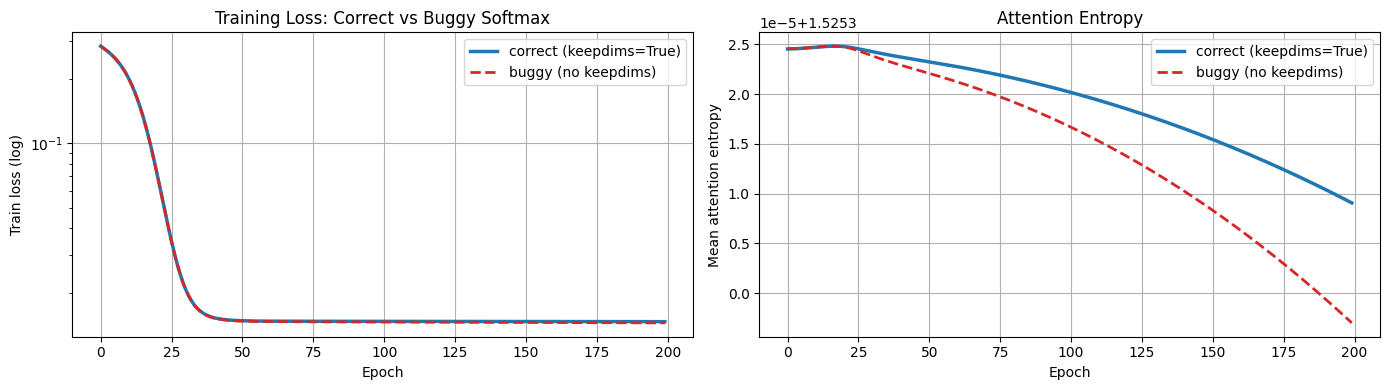

In [25]:
# Plot styles
colors = {"correct (keepdims=True)": "tab:blue", "buggy (no keepdims)": "tab:red"}
styles = {"correct (keepdims=True)": "-", "buggy (no keepdims)": "--"}
widths = {"correct (keepdims=True)": 2.5, "buggy (no keepdims)": 2.0}

# Loss and entropy
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, res in comparison.items():
    axes[0].plot(res["loss_history"], styles[label], color=colors[label],
                 linewidth=widths[label], label=label)
    axes[1].plot(res["entropy_history"], styles[label], color=colors[label],
                 linewidth=widths[label], label=label)

axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss (log)")
axes[0].set_title("Training Loss: Correct vs Buggy Softmax")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean attention entropy")
axes[1].set_title("Attention Entropy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

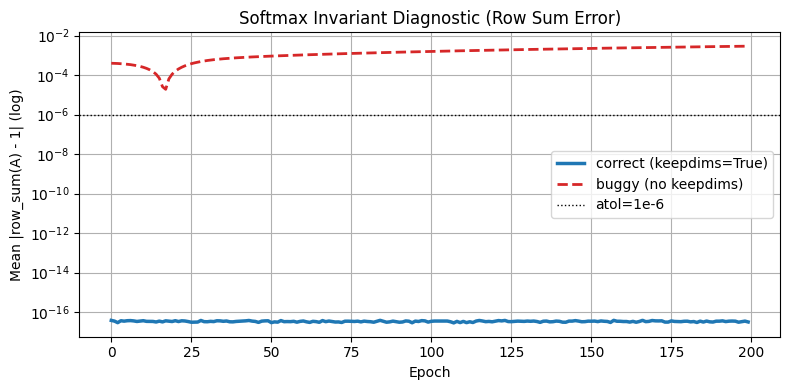

In [26]:
# Instrument: plot the row-stochasticity error over training (bug detector)

eps = 1e-20
plt.figure(figsize=(8, 4))

for label, res in comparison.items():
    is_buggy = "buggy" in label.lower()
    style = "--" if is_buggy else "-"
    color = "tab:red" if is_buggy else "tab:blue"
    lw = 2.0 if is_buggy else 2.5

    y = np.maximum(np.array(res["rowsum_error_history"], dtype=np.float64), eps)
    plt.semilogy(y, style, color=color, linewidth=lw, label=label)

plt.axhline(1e-6, color="k", linestyle=":", linewidth=1.0, label="atol=1e-6")
plt.xlabel("Epoch")
plt.ylabel("Mean |row_sum(A) - 1| (log)")
plt.title("Softmax Invariant Diagnostic (Row Sum Error)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


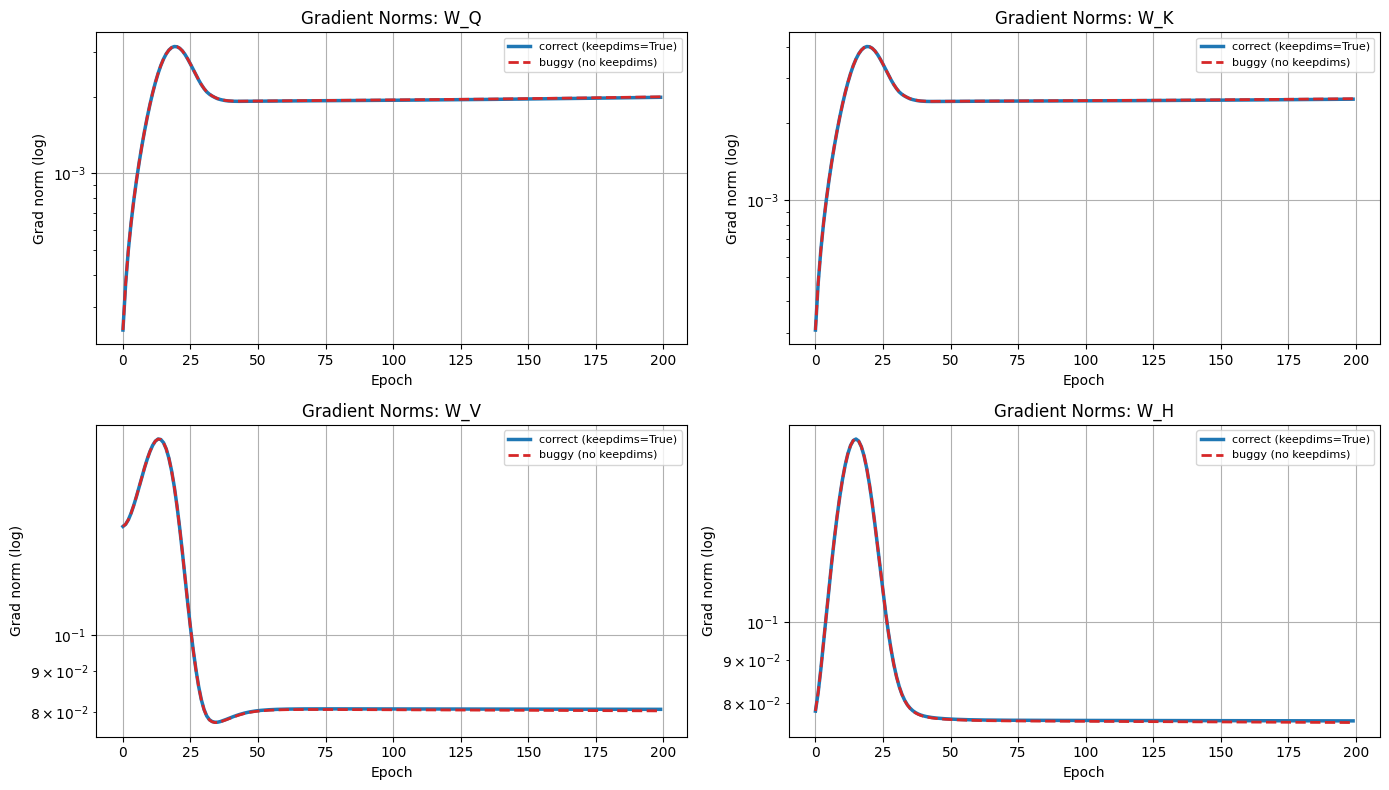

In [27]:
# Gradient norms by weight matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
    ax = axes[idx // 2][idx % 2]
    for label, res in comparison.items():
        ax.plot(res["grad_norm_history"][wname], styles[label], color=colors[label],
                linewidth=widths[label], label=label)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Grad norm (log)")
    ax.set_title(f"Gradient Norms: {wname}")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 2.5 Inspecting Attention Patterns

In [28]:
for label, res in comparison.items():
    wq, wk, wv, wh = res["weights"]
    sfn = row_softmax_buggy if "buggy" in label else None

    print(f"\n{'='*55}")
    print(f"  {label}  |  test MSE = {res['test_mse']:.6f}")
    print(f"{'='*55}")

    x_t, y_t = test_set[0]
    hidden_t, target_t = make_hidden_and_target(x_t, y_t, W_embed, scale=scale_train)
    pred_t, cache_t = attention_forward(
        hidden_t, wq, wk, wv, wh,
        return_cache=True, softmax_fn=sfn
    )

    print(f"\nInput x: {x_t}")
    print(f"Target y (argmax broadcast): {y_t}")
    print(f"\nAttention weights A (row sums shown):")
    print(np.round(cache_t['A'], 4))
    print(f"Row sums: {np.round(cache_t['A'].sum(axis=1), 4)}")

    yhat = decode_embedding_to_scalar(pred_t, W_embed, scale=scale_train)
    print(f"\nPrediction (decoded): {np.round(yhat, 3)}")


  correct (keepdims=True)  |  test MSE = 0.021226

Input x: [5 9 5 1 6 4]
Target y (argmax broadcast): [9 9 9 9 9 9]

Attention weights A (row sums shown):
[[0.1667 0.168  0.1667 0.1653 0.167  0.1663]
 [0.1667 0.1692 0.1667 0.1642 0.1673 0.166 ]
 [0.1667 0.168  0.1667 0.1653 0.167  0.1663]
 [0.1667 0.1669 0.1667 0.1664 0.1667 0.1666]
 [0.1667 0.1683 0.1667 0.165  0.1671 0.1663]
 [0.1667 0.1678 0.1667 0.1656 0.1669 0.1664]]
Row sums: [1. 1. 1. 1. 1. 1.]

Prediction (decoded): [7.943 7.958 7.943 7.928 7.947 7.939]

  buggy (no keepdims)  |  test MSE = 0.020985

Input x: [5 9 5 1 6 4]
Target y (argmax broadcast): [9 9 9 9 9 9]

Attention weights A (row sums shown):
[[0.1667 0.1692 0.1667 0.1642 0.1673 0.166 ]
 [0.1656 0.1692 0.1656 0.162  0.1665 0.1647]
 [0.1667 0.1692 0.1667 0.1642 0.1673 0.166 ]
 [0.1678 0.1692 0.1678 0.1664 0.1681 0.1674]
 [0.1664 0.1692 0.1664 0.1636 0.1671 0.1657]
 [0.1669 0.1692 0.1669 0.1647 0.1675 0.1664]]
Row sums: [1.     0.9934 1.     1.0067 0.9984 1.0017]

Pr

---

## 2.6 Summary

### What We Learned

1. **The bug:** Missing `keepdims=True` causes NumPy to broadcast division across columns instead of rows

2. **Symptom:** Attention rows don't sum to 1 → not valid probability distributions

3. **Training impact:** 
   - Buggy version may still decrease loss (gradient flow isn't zero)
   - But the attention patterns are meaningless
   - Final test MSE is typically worse

### Key Takeaway

Shape mismatches in softmax are **silent bugs** — NumPy doesn't error, it just broadcasts incorrectly. Always verify:
```python
assert np.allclose(A.sum(axis=1), 1.0), "Softmax rows must sum to 1!"
```

---

## Next: Part 3 — Gradient Signal & Tuning

We fixed the broadcasting bug and softmax now works correctly. But if you look closely at the training curves, you might notice something strange: **attention entropy stays nearly constant**, as if the attention isn't learning to focus.

Why would loss decrease while attention patterns don't change? Something deeper is going on. Time to investigate.